# Ejercicio 05 · Motor recomendador reproducible

INF-8239 Ciencia de Datos II · Unidad 03 · Consolidación de LAB08 y LAB09.

Este notebook **recalcula** la auditoría, el corte temporal, los baselines y una corrida completa del híbrido, y **carga** la comparación de 27 corridas (3 factores × 3 alphas × 3 semillas) que genera `scripts/lab09_experiments.py` (~15 min). Todo el código vive en `src/inf8239_u03/`; el notebook solo lo invoca.

Requisitos previos:
```bash
uv sync
uv run python scripts/download_data.py
uv run python scripts/lab08_content.py
uv run python scripts/lab09_experiments.py
```

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from inf8239_u03.config import MOVIELENS_DIR, RANDOM_STATE, ROOT
from inf8239_u03.data import load_movielens
from inf8239_u03.recommenders import (
    ContentRecommender,
    run_experiment,
    temporal_leave_one_out,
    weighted_popularity,
)

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)
REPORTS = ROOT / "reports"
print("Datos:", MOVIELENS_DIR.relative_to(ROOT), "| semilla por defecto:", RANDOM_STATE)

Datos: data\raw\ml-latest-small | semilla por defecto: 42


## 1. Datos, licencia y auditoría

MovieLens Latest Small (GroupLens, uso académico no comercial; cita Harper & Konstan, 2015). Los CSV no se versionan: se descargan con `download_data.py`, que registra el SHA-256. `load_movielens` valida columnas, integridad referencial y rango de ratings. Detalle en `docs/DATASET_CARD.md`.

In [2]:
ratings, movies = load_movielens(MOVIELENS_DIR)
users, rated = ratings["userId"].nunique(), ratings["movieId"].nunique()
audit = pd.Series({
    "ratings": len(ratings),
    "usuarios": users,
    "películas en catálogo": len(movies),
    "películas valoradas": rated,
    "películas sin ratings": len(movies) - rated,
    "densidad (%)": round(100 * len(ratings) / (users * len(movies)), 2),
    "mínimo de ratings por usuario": int(ratings.groupby("userId").size().min()),
    "rating medio": round(ratings["rating"].mean(), 3),
    "desviación": round(ratings["rating"].std(), 3),
    "desde": pd.to_datetime(ratings["timestamp"].min(), unit="s").date(),
    "hasta": pd.to_datetime(ratings["timestamp"].max(), unit="s").date(),
})
audit.to_frame("valor")

,valor
ratings,100836
usuarios,610
películas en catálogo,9742
películas valoradas,9724
películas sin ratings,18
densidad (%),1.7
mínimo de ratings por usuario,20
rating medio,3.502
desviación,1.043
desde,1996-03-29


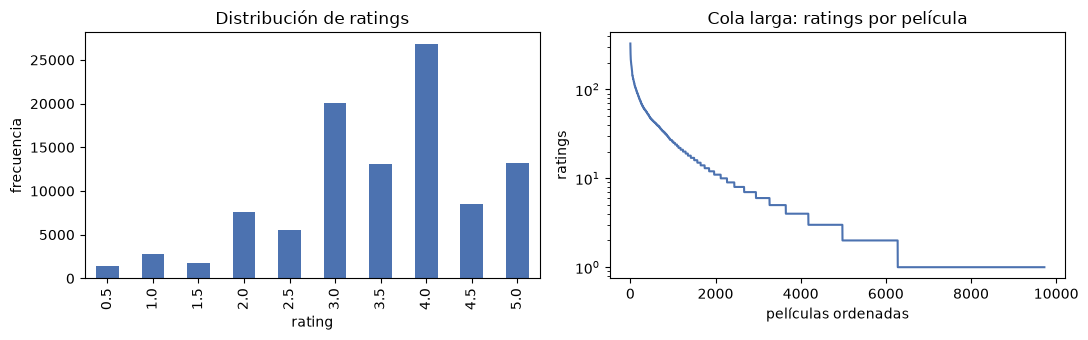

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
ratings["rating"].value_counts().sort_index().plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set(title="Distribución de ratings", xlabel="rating", ylabel="frecuencia")
counts = ratings.groupby("movieId").size().sort_values(ascending=False).reset_index(drop=True)
axes[1].plot(counts.index, counts.values, color="#4C72B0")
axes[1].set(title="Cola larga: ratings por película", xlabel="películas ordenadas", ylabel="ratings", yscale="log")
plt.tight_layout()

## 2. Corte temporal

Leave-one-out temporal: la **última** valoración de cada usuario va a prueba y el resto a entrenamiento. Un corte aleatorio permitiría aprender del futuro para explicar el pasado. Solo se evalúan usuarios cuya película retenida tiene ratings en entrenamiento (si no, no existe factor latente para ella).

In [4]:
train, test = temporal_leave_one_out(ratings)
evaluable = test[test["movieId"].isin(train["movieId"])]
leak = (test.set_index("userId")["timestamp"] < train.groupby("userId")["timestamp"].max()).sum()
pd.Series({
    "entrenamiento": len(train),
    "prueba (1 por usuario)": len(test),
    "usuarios evaluables": len(evaluable),
    "excluidos: película retenida sin ratings previos": len(test) - len(evaluable),
    "ítems en entrenamiento (denominador de cobertura)": train["movieId"].nunique(),
    "usuarios con prueba anterior a su entrenamiento": int(leak),
}).to_frame("valor")

,valor
entrenamiento,100226
prueba (1 por usuario),610
usuarios evaluables,587
excluidos: película retenida sin ratings previos,23
ítems en entrenamiento (denominador de cobertura),9701
usuarios con prueba anterior a su entrenamiento,0


## 3. Baselines de LAB08: popularidad y contenido

**Popularidad ponderada:** promedio bayesiano que acerca a la media global las películas con pocos ratings. Sin suavizado, el top lo ocupan películas con 12–20 ratings.

In [5]:
popular = weighted_popularity(ratings, movies)
by_mean = popular.sort_values("mean", ascending=False)
pd.concat(
    {"suavizada": popular.head(5)[["title", "count", "mean", "weighted_score"]].reset_index(drop=True),
     "media simple": by_mean.head(5)[["title", "count", "mean"]].reset_index(drop=True)},
    axis=1,
)

suavizada                                                     media simple                
                                       title count      mean weighted_score                             title count      mean
0           Shawshank Redemption, The (1994)   317  4.429022       4.395194             Paths of Glory (1957)    12  4.541667
1                      Godfather, The (1972)   192  4.289062       4.242739  Streetcar Named Desire, A (1951)    20  4.475000
2                          Fight Club (1999)   218  4.272936       4.232690  Celebration, The (Festen) (1998)    12  4.458333
3  Star Wars: Episode IV - A New Hope (1977)   251  4.231076       4.197790                        Ran (1985)    15  4.433333
4                 Usual Suspects, The (1995)   204  4.237745       4.196846  Shawshank Redemption, The (1994)   317  4.429022

**Contenido:** TF-IDF de géneros + similitud coseno. Solo hay 20 géneros, así que muchas películas comparten vector y empatan en 1.0; LAB08 desempata por popularidad suavizada (`reports/content_recommendations.csv`).

In [6]:
content = ContentRecommender().fit(movies)
toy = content.recommend("Toy Story (1995)", len(movies))
print("Películas con similitud 1.0 a Toy Story:", int((toy["content_score"].round(6) == 1).sum()))
display(pd.read_csv(REPORTS / "content_ties.csv"))
pd.read_csv(REPORTS / "content_recommendations.csv").query("query == 'Toy Story (1995)'")[["rank", "title", "content_score", "count", "weighted_score"]]

Películas con similitud 1.0 a Toy Story: 12


,query,genres,top_score,tied_movies
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1.0,12
1,Heat (1995),Action|Crime|Thriller,1.0,65
2,Sabrina (1995),Comedy|Romance,1.0,362


,rank,title,content_score,count,weighted_score
0,1,"Monsters, Inc. (2001)",1.0,132,3.840408
1,2,Toy Story 2 (1999),1.0,97,3.821272
2,3,"Emperor's New Groove, The (2000)",1.0,37,3.663647
3,4,Asterix and the Vikings (Astérix et les Viking...,1.0,1,3.616822
4,5,Moana (2016),1.0,10,3.478122
5,6,"Tale of Despereaux, The (2008)",1.0,1,3.462976
6,7,"Wild, The (2006)",1.0,1,3.424514
7,8,Turbo (2013),1.0,1,3.424514
8,9,The Good Dinosaur (2015),1.0,4,3.376168
9,10,Antz (1998),1.0,45,3.298573


## 4. Corrida completa de LAB09 (f=20, α=0.75, semilla 42)

Se entrenan la factorización matricial y se evalúan las cuatro estrategias con el **mismo** corte y los mismos usuarios. Tarda alrededor de un minuto.

In [7]:
rows, recommender = run_experiment(ratings, movies, factors=20, epochs=12, alphas=[0.25, 0.75], seed=42)
live = pd.DataFrame(rows)
live[["method", "alpha", "rmse", "rmse_global_mean", "rmse_item_mean", "hit_rate_at_10", "precision_at_10",
      "catalog_coverage", "mean_item_popularity", "train_seconds", "model_size_kb"]].round(4)

,method,alpha,rmse,rmse_global_mean,rmse_item_mean,hit_rate_at_10,precision_at_10,catalog_coverage,mean_item_popularity,train_seconds,model_size_kb
0,popularity,NaN,NaN,1.1157,1.0503,0.0426,0.0043,0.0122,233.3186,0.0000,75.7891
1,content,NaN,NaN,1.1157,1.0503,0.0051,0.0005,0.0826,32.4363,0.0000,310.1562
2,collaborative,NaN,1.0264,1.1157,1.0503,0.0375,0.0037,0.0746,136.3112,59.8637,1611.0938
3,hybrid,0.25,1.0264,1.1157,1.0503,0.0324,0.0032,0.1065,95.9670,59.8637,1921.2500
4,hybrid,0.75,1.0264,1.1157,1.0503,0.0375,0.0037,0.0775,134.6746,59.8637,1921.2500


**Errores de rating:** la factorización (RMSE ≈ 1.026) mejora poco sobre predecir la media de cada película (1.050) y la media global (1.116). **Ranking:** ninguna estrategia personalizada supera a la popularidad en HitRate@10; el contenido solo casi no acierta. Precision@10 = HitRate@10 / 10 porque hay un único ítem relevante por usuario.

In [8]:
saved = pd.read_csv(REPORTS / "lab09_runs.csv").query("factors == 20 and seed == 42")
check = live.merge(saved, on=["method", "alpha"], suffixes=("_notebook", "_reporte"))
check["igual"] = (check["hit_rate_at_10_notebook"] - check["hit_rate_at_10_reporte"]).abs() < 1e-12
print("Reproducibilidad frente a reports/lab09_runs.csv:")
check[["method", "alpha", "hit_rate_at_10_notebook", "hit_rate_at_10_reporte", "igual"]]

Reproducibilidad frente a reports/lab09_runs.csv:


,method,alpha,hit_rate_at_10_notebook,hit_rate_at_10_reporte,igual
0,popularity,NaN,0.042589,0.042589,True
1,content,NaN,0.005111,0.005111,True
2,collaborative,NaN,0.037479,0.037479,True
3,hybrid,0.25,0.032368,0.032368,True
4,hybrid,0.75,0.037479,0.037479,True


## 5. Tres semillas, alpha y Pareto

`reports/lab09_summary.csv` resume 27 corridas. Utilidad = (HitRate@10, cobertura); costo = (tiempo de entrenamiento, tamaño). Una configuración está dominada si otra es igual o mejor en ambas utilidades con igual o menor costo.

In [9]:
summary = pd.read_csv(REPORTS / "lab09_summary.csv")
summary[["config", "seeds", "rmse_mean", "hit_rate_at_10_mean", "hit_rate_at_10_std", "catalog_coverage_mean",
         "mean_item_popularity_mean", "train_seconds_mean", "model_size_kb_mean", "pareto_optimal", "dominated_by"]].round(4)

,config,seeds,rmse_mean,hit_rate_at_10_mean,hit_rate_at_10_std,catalog_coverage_mean,mean_item_popularity_mean,train_seconds_mean,model_size_kb_mean,pareto_optimal,dominated_by
0,popularity,3,NaN,0.0426,0.0000,0.0122,233.3186,0.0000,75.7891,True,NaN
1,hybrid f=10 a=0.75,3,1.0322,0.0403,0.0094,0.0557,140.8840,52.8158,1115.7031,True,NaN
2,hybrid f=40 a=0.5,3,1.0213,0.0403,0.0052,0.1055,110.7868,68.2895,3532.3438,True,NaN
3,collaborative f=10,3,1.0322,0.0392,0.0051,0.0536,142.9334,52.8158,805.5469,True,NaN
4,hybrid f=40 a=0.75,3,1.0213,0.0386,0.0060,0.0974,121.0698,68.2895,3532.3438,False,hybrid f=40 a=0.5
5,collaborative f=40,3,1.0213,0.0363,0.0084,0.0976,122.7909,68.2895,3222.1875,True,NaN
6,collaborative f=20,3,1.0261,0.0352,0.0055,0.0701,137.5969,48.7155,1611.0938,True,NaN
7,hybrid f=20 a=0.75,3,1.0261,0.0352,0.0055,0.0723,135.8751,48.7155,1921.2500,True,NaN
8,hybrid f=20 a=0.5,3,1.0261,0.0346,0.0100,0.0837,123.0973,48.7155,1921.2500,True,NaN
9,hybrid f=10 a=0.5,3,1.0322,0.0335,0.0060,0.0653,128.0876,52.8158,1115.7031,True,NaN


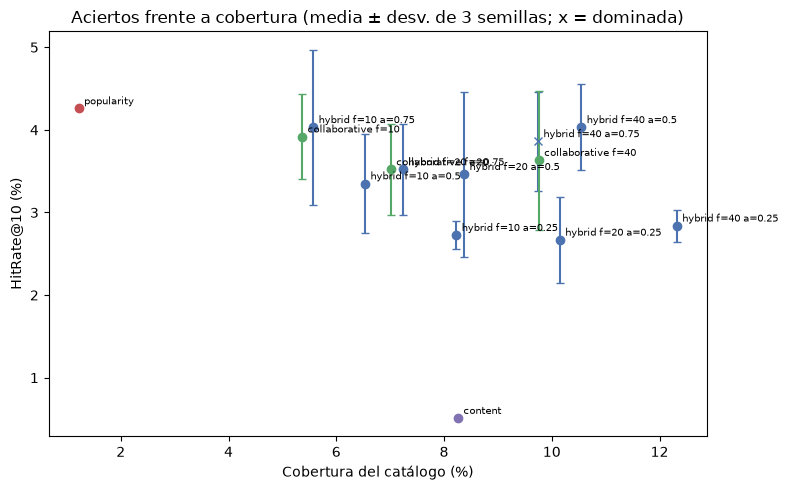

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"popularity": "#C44E52", "content": "#8172B2", "collaborative": "#55A868", "hybrid": "#4C72B0"}
for _, row in summary.iterrows():
    ax.errorbar(100 * row["catalog_coverage_mean"], 100 * row["hit_rate_at_10_mean"],
                yerr=100 * (row["hit_rate_at_10_std"] if pd.notna(row["hit_rate_at_10_std"]) else 0),
                fmt="o" if row["pareto_optimal"] else "x", color=colors[row["method"]], capsize=3)
    ax.annotate(row["config"], (100 * row["catalog_coverage_mean"], 100 * row["hit_rate_at_10_mean"]),
                fontsize=7, xytext=(4, 3), textcoords="offset points")
ax.set(xlabel="Cobertura del catálogo (%)", ylabel="HitRate@10 (%)",
       title="Aciertos frente a cobertura (media ± desv. de 3 semillas; x = dominada)")
plt.tight_layout()

In [11]:
alpha_table = summary[summary["method"].eq("hybrid")].pivot_table(
    index="factors", columns="alpha", values=["hit_rate_at_10_mean", "catalog_coverage_mean"])
(100 * alpha_table).round(2)

catalog_coverage_mean              hit_rate_at_10_mean            
alpha                    0.25   0.50  0.75                0.25  0.50  0.75
factors                                                                   
10.0                     8.23   6.53  5.57                2.73  3.35  4.03
20.0                    10.15   8.37  7.23                2.67  3.46  3.52
40.0                    12.32  10.55  9.74                2.84  4.03  3.86

**Alpha:** en los tres tamaños α=0.75 acierta más que α=0.25 (+0.85 a +1.3 pp, más que la desviación entre semillas) y α=0.25 cubre más catálogo. Alpha intercambia acierto por amplitud. **Costo:** pasar de 10 a 40 factores triplica el tamaño sin mejorar el mejor HitRate; solo gana cobertura. El tiempo de entrenamiento tiene ruido de carga de la máquina.

## 6. Usuarios fríos y tres perfiles

In [12]:
profiles = pd.read_csv(REPORTS / "lab09_profiles.csv")
example = profiles.query("method == 'hybrid' and factors == 20 and alpha == 0.75 and seed == 42")
example.pivot(index="rank", columns="profile", values="title")

profile,historial_amplio,historial_pequeno,usuario_nuevo
rank,,,
1,Life Is Beautiful (La Vita è bella) (1997),"Godfather, The (1972)",Forrest Gump (1994)
2,12 Angry Men (1957),Annie Hall (1977),"Shawshank Redemption, The (1994)"
3,My Fair Lady (1964),Apocalypse Now (1979),Pulp Fiction (1994)
4,Intouchables (2011),Slumdog Millionaire (2008),"Matrix, The (1999)"
5,Annie Hall (1977),Rocky (1976),"Silence of the Lambs, The (1991)"
6,"Philadelphia Story, The (1940)",Match Point (2005),Star Wars: Episode IV - A New Hope (1977)
7,Psycho (1960),Goodfellas (1990),Braveheart (1995)
8,"Lives of Others, The (Das leben der Anderen) (...",2001: A Space Odyssey (1968),Jurassic Park (1993)
9,Ben-Hur (1959),Punch-Drunk Love (2002),Terminator 2: Judgment Day (1991)


In [13]:
stability = pd.read_csv(REPORTS / "lab09_profile_stability.csv")
stability.query("factors == 20")[["profile", "alpha", "history_size", "personalized", "jaccard_between_seeds",
                                  "overlap_with_content_top10", "any_seen_item"]].round(3)

,profile,alpha,history_size,personalized,jaccard_between_seeds,overlap_with_content_top10,any_seen_item
3,historial_amplio,0.25,2697,True,0.465,0.133,False
4,historial_amplio,0.50,2697,True,0.624,0.100,False
5,historial_amplio,0.75,2697,True,0.624,0.100,False
12,historial_pequeno,0.25,19,True,0.000,0.000,False
13,historial_pequeno,0.50,19,True,0.000,0.000,False
14,historial_pequeno,0.75,19,True,0.000,0.000,False
21,usuario_nuevo,0.25,0,False,1.000,1.000,False
22,usuario_nuevo,0.50,0,False,1.000,1.000,False
23,usuario_nuevo,0.75,0,False,1.000,1.000,False


- **Usuario nuevo:** recibe la lista de popularidad, igual en todas las semillas y marcada como no personalizada (`reports/cold_start_fallback.csv`).
- **Historial amplio:** sin ítems vistos y moderadamente estable entre semillas.
- **Historial pequeño (19 ratings):** sin ítems vistos pero con Jaccard 0 entre semillas: sus factores son casi ruido de inicialización.
- **Ítems fríos:** 18 películas sin ratings no pueden aparecer en ninguna estrategia de LAB09.

## 7. Decisión final y límites

- **Decisión:** híbrido con 40 factores y α=0.5. Iguala el mejor HitRate híbrido, duplica la cobertura del f=10 α=0.75 y concentra menos lo popular. Alternativa Green AI: f=10 α=0.75. Fallback de popularidad para usuarios nuevos o con poco historial.
- **Límites:** ninguna configuración supera a la popularidad en aciertos; la factorización no tiene sesgos de usuario/ítem; un solo ítem retenido por usuario hace ruidoso el HitRate (0.17 pp por acierto); sin demografía no puede evaluarse equidad; el dataset es de desarrollo y de una población no representativa.
- Detalle completo en `README.md` (redacción LAB09) y `docs/SYSTEM_CARD.md`.